# Module 2 — Patient Stratification / Clustering (PySpark)

## Pipeline
```
mimic-iv-3.1.zip
    ↓  extract_zip()         [Python zipfile]
mimic_extracted/*.csv.gz
    ↓  Spark read CSV        [song song, lazy]
Spark DataFrames (20M rows)
    ↓  groupBy + pivot       [Spark song song]
Spark pivot (211k × 100)
    ↓  .toPandas()           [collect SAU aggregate]
pandas (211k × 102)
    ↓  StandardScaler + PCA  [sklearn]
X_pca / X_scaled / X_binary
    ↓  KMeans + Hierarchical [sklearn]
Clusters + patient_clusters.csv
```

## Tại sao dùng PySpark?
| Bước | pandas chunks | PySpark |
|------|--------------|----------|
| Đọc file | Tuần tự 1 thread | Song song N thread |
| groupBy / count | Counter() 1 thread | Distributed groupBy |
| pivot / join | Merge pandas | Spark join song song |
| StandardScaler / PCA | sklearn (giữ nguyên) | sklearn (giữ nguyên) |

## Cell 1 — Import

In [ ]:
import sys, warnings
sys.path.append('.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from datetime import datetime

# Module 2 components
from module2.settings   import Settings
from module2.reader     import (create_spark, extract_zip,
                                load_patients_spark, load_diagnoses_spark,
                                load_prescriptions_spark, compute_top_tokens_spark)
from module2.vectorizer import PatientVectorizer
from module2.model      import PatientClustering, find_best_k, auto_best_k
from module2.plots      import (plot_eda, plot_pca_variance, plot_choose_k,
                                plot_metric_comparison, plot_dendrogram,
                                plot_cluster_heatmap, plot_tsne, plot_distribution)

print('Import thanh cong!')

Import thanh cong!


## Cell 2 — Cấu hình
**Chỉ cần sửa `zip_path`**

In [2]:
settings = Settings(
    zip_path = Path(r"C:\Users\DELL\Downloads\codedll\mimic-iv-3.1.zip"),

    # Thư mục giải nén tạm (Spark không đọc được file trong zip)
    extracted_dir = Path(r"C:\Users\DELL\Downloads\codedll\mimic_extracted"),

    output_dir     = Path("output_module2"),

    # PySpark config
    spark_driver_memory   = "8g",
    spark_executor_memory = "4g",
    spark_cores           = "4",

    top_icd        = 50,
    top_drug       = 50,
    limit_patients = None,

    pca_dims       = 20,
    k_range_min    = 2,
    k_range_max    = 9,
    best_k         = 4,
    random_state   = 42,

    use_euclidean  = True,
    use_cosine     = True,
    use_jaccard    = True,

    tsne_sample    = 5_000,
    dendro_sample  = 200,
    cosine_sample  = 5_000,
    jaccard_sample = 3_000,
)

settings.output_dir.mkdir(exist_ok=True)
settings.extracted_dir.mkdir(exist_ok=True, parents=True)
print(f"zip_path      : {settings.zip_path}")
print(f"extracted_dir : {settings.extracted_dir}")
print(f"output_dir    : {settings.output_dir}")

zip_path      : C:\Users\DELL\Downloads\codedll\mimic-iv-3.1.zip
extracted_dir : C:\Users\DELL\Downloads\codedll\mimic_extracted
output_dir    : output_module2


## Cell 3 — Khởi động PySpark
Lần đầu khởi động mất ~30 giây (JVM startup)

In [3]:
spark = create_spark(
    driver_memory   = settings.spark_driver_memory,
    executor_memory = settings.spark_executor_memory,
    cores           = settings.spark_cores,
)

# Kiểm tra Spark hoạt động
test_df = spark.range(5)
print("Spark test:", test_df.collect())
print("Spark UI: http://localhost:4040")

SparkSession OK  — version=3.5.1  master=local[4]
Spark test: [Row(id=0), Row(id=1), Row(id=2), Row(id=3), Row(id=4)]
Spark UI: http://localhost:4040


## Cell 4 — Giải nén ZIP
Bước này chạy 1 lần duy nhất. Lần sau bỏ qua (đã có file).

In [4]:
print("Giai nen cac file can thiet tu zip...")
print("(Spark khong doc duoc file ben trong .zip truc tiep)")
print("(Chi giai nen 3 file can thiet, khong phai toan bo zip)")
print()

hosp_dir = extract_zip(
    zip_path    = settings.zip_path,
    extract_to  = settings.extracted_dir,
    files_needed = [
        "patients.csv.gz",
        "diagnoses_icd.csv.gz",
        "prescriptions.csv.gz",
    ]
)

print(f"\nCac file san sang tai: {hosp_dir}")
for f in ["patients.csv.gz", "diagnoses_icd.csv.gz", "prescriptions.csv.gz"]:
    p = hosp_dir / f
    if p.exists():
        print(f"  OK  {f}  ({p.stat().st_size/1024**2:.0f} MB)")
    else:
        print(f"  MISS {f}")

Giai nen cac file can thiet tu zip...
(Spark khong doc duoc file ben trong .zip truc tiep)
(Chi giai nen 3 file can thiet, khong phai toan bo zip)

ZIP prefix: 'mimic-iv-3.1/hosp/'
  Đã có: patients.csv.gz → bỏ qua
  Đã có: diagnoses_icd.csv.gz → bỏ qua
  Đã có: prescriptions.csv.gz → bỏ qua
Giải nén xong → C:\Users\DELL\Downloads\codedll\mimic_extracted/

Cac file san sang tai: C:\Users\DELL\Downloads\codedll\mimic_extracted
  OK  patients.csv.gz  (3 MB)
  OK  diagnoses_icd.csv.gz  (32 MB)
  OK  prescriptions.csv.gz  (578 MB)


## Cell 5 — Đọc dữ liệu bằng Spark
Spark đọc lazy (không load vào RAM ngay). Chỉ tính khi có action (.show, .count, .collect)

In [5]:
# ── Patients ──
print("Doc patients (Spark lazy read)...")
patients_sdf = load_patients_spark(spark, hosp_dir, limit=settings.limit_patients)
n_patients   = patients_sdf.count()   # action → Spark thực sự đọc file
print(f"  {n_patients:,} benh nhan")
patients_sdf.show(3)

# ── Diagnoses ──
print("\nDoc diagnoses (Spark lazy read)...")
icd_sdf   = load_diagnoses_spark(spark, hosp_dir)
n_icd     = icd_sdf.count()
n_uniq    = icd_sdf.select("icd_token").distinct().count()
print(f"  {n_icd:,} records  unique tokens: {n_uniq:,}")
icd_sdf.show(3)

# ── Prescriptions ──
print("\nDoc prescriptions (Spark lazy read)... mat 1-2 phut")
drug_sdf, drug_col = load_prescriptions_spark(spark, hosp_dir)
n_drug    = drug_sdf.count()
n_uniq_d  = drug_sdf.select("drug_token").distinct().count()
print(f"  Drug column: '{drug_col}'")
print(f"  {n_drug:,} records  unique tokens: {n_uniq_d:,}")
drug_sdf.show(3)

print("\nDoc du lieu xong!")

Doc patients (Spark lazy read)...
  364,627 benh nhan
+----------+---+----------+
|subject_id|age|gender_num|
+----------+---+----------+
|  10000032| 52|         0|
|  10000048| 23|         0|
|  10000058| 33|         0|
+----------+---+----------+
only showing top 3 rows


Doc diagnoses (Spark lazy read)...
  6,364,488 records  unique tokens: 28,583
+----------+----------+
|subject_id| icd_token|
+----------+----------+
|  10000032| ICD9:5723|
|  10000032|ICD9:78959|
|  10000032| ICD9:5715|
+----------+----------+
only showing top 3 rows


Doc prescriptions (Spark lazy read)... mat 1-2 phut
  Drug column: 'formulary_drug_cd'
  20,268,046 records  unique tokens: 4,205
+----------+-------------+
|subject_id|   drug_token|
+----------+-------------+
|  10000032|DRUGCD:FURO40|
|  10000032|DRUGCD:IPRA2H|
|  10000032|DRUGCD:FURO20|
+----------+-------------+
only showing top 3 rows


Doc du lieu xong!


## Cell 6 — Tính top tokens bằng Spark groupBy

In [6]:
print("Tinh top ICD codes bang Spark groupBy...")
top_icd_codes = compute_top_tokens_spark(
    df           = icd_sdf,
    token_col    = "icd_token",
    valid_pids_df = patients_sdf,
    top_n        = settings.top_icd,
)
print(f"  Top {len(top_icd_codes)} ICD: {top_icd_codes[:5]} ...")

print("\nTinh top Drug codes bang Spark groupBy...")
top_drug_codes = compute_top_tokens_spark(
    df           = drug_sdf,
    token_col    = "drug_token",
    valid_pids_df = patients_sdf,
    top_n        = settings.top_drug,
)
print(f"  Top {len(top_drug_codes)} Drug: {top_drug_codes[:5]} ...")

print("\nTop tokens xong!")

Tinh top ICD codes bang Spark groupBy...
  Top 50 ICD: ['ICD9:4019', 'ICD10:E785', 'ICD10:I10', 'ICD9:2724', 'ICD10:Z87891'] ...

Tinh top Drug codes bang Spark groupBy...
  Top 50 Drug: ['DRUGCD:NACLFLUSH', 'DRUGCD:HEPA5I', 'DRUGCD:ACET325', 'DRUGCD:DOCU100', 'DRUGCD:SENN187'] ...

Top tokens xong!


## Cell 7 — Feature Engineering (Spark ETL + sklearn)
Spark làm pivot + join → collect về pandas → sklearn StandardScaler + PCA

In [8]:
vec = PatientVectorizer(pca_dims=settings.pca_dims, random_state=settings.random_state)

vec.fit_transform(
    spark          = spark,
    patients_sdf   = patients_sdf,
    icd_sdf        = icd_sdf,
    drug_sdf       = drug_sdf,
    top_icd_codes  = top_icd_codes,
    top_drug_codes = top_drug_codes,
    limit_patients = settings.limit_patients,
)

# Lưu cluster_kmeans vào feature_df sau này
print("Feature engineering xong!")

[1/5] Chuẩn bị dữ liệu Spark...
      top ICD codes  : 50
      top Drug codes : 50
[2/5] Pivot ICD (Spark)...
[3/5] Pivot Drug (Spark)...
[4/5] Join base + ICD + Drug (Spark)...
[5/5] Collect về pandas (sau aggregate)...

Feature matrix  : (211485, 103)
  age + gender  : 2
  ICD features  : 50
  Drug features : 50
X_scaled shape  : (211485, 102)
X_pca shape     : (211485, 20)
PCA variance    : 51.6%
Feature engineering xong!


## Cell 8 — EDA

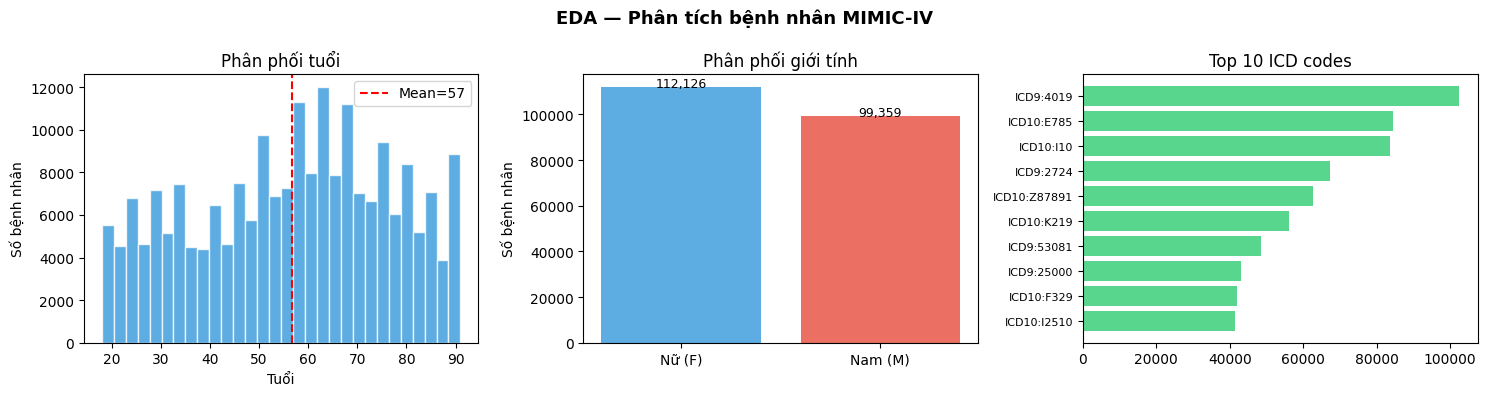

  Lưu: output_module2\01_eda.png


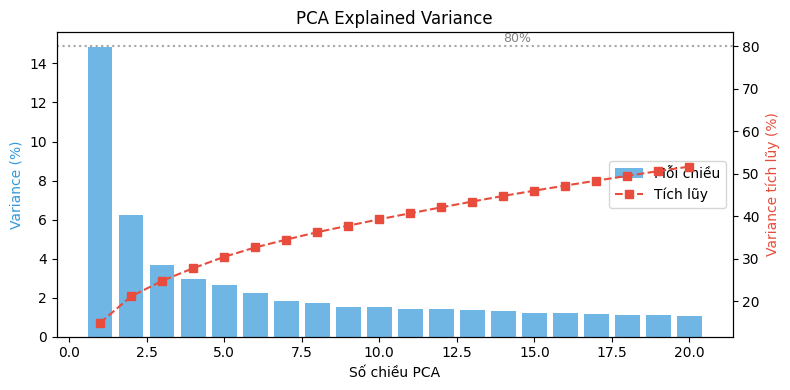

  Lưu: output_module2\02_pca_variance.png


In [9]:
icd_pdf = icd_sdf.toPandas()   # dùng cho EDA plot
plot_eda(vec.feature_df, icd_pdf, settings.output_dir)
plot_pca_variance(vec.pca, settings.output_dir)

## Cell 9 — Tìm K tối ưu

Tim K toi uu... 
  K=2: inertia=841,950  silhouette=0.3042  davies_bouldin=1.8677
  K=3: inertia=767,876  silhouette=0.2775  davies_bouldin=2.0738
  K=4: inertia=722,101  silhouette=0.1772  davies_bouldin=2.1955
  K=5: inertia=696,006  silhouette=0.1750  davies_bouldin=2.3068
  K=6: inertia=669,271  silhouette=0.1208  davies_bouldin=2.3792
  K=7: inertia=647,524  silhouette=0.0726  davies_bouldin=2.2930
  K=8: inertia=625,645  silhouette=0.0831  davies_bouldin=2.3159

K toi uu (Silhouette): 2
K toi uu (DB thap nhat): 2


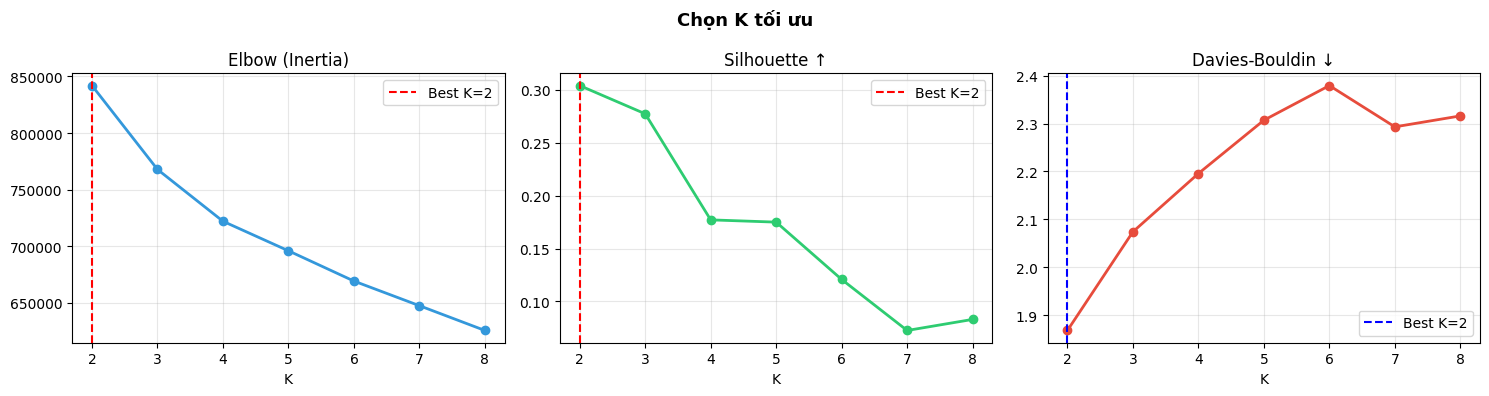

  Lưu: output_module2\03_choose_K.png

Xem bieu do 


In [10]:
print("Tim K toi uu... ")

k_range = range(settings.k_range_min, settings.k_range_max)
inertia_d, sil_d, db_d = find_best_k(
    vec.X_pca,
    k_range      = k_range,
    random_state = settings.random_state,
    sample_size  = 20_000,
)

BEST_K = auto_best_k(sil_d)
print(f"\nK toi uu (Silhouette): {BEST_K}")
print(f"K toi uu (DB thap nhat): {min(db_d, key=db_d.get)}")

plot_choose_k(inertia_d, sil_d, db_d, BEST_K, settings.output_dir)
print("\nXem bieu do ")

## Cell 10 — Fit 3 Clustering Models
Có thể ép `BEST_K = 4` nếu muốn theo yêu cầu đề bài


FIT CLUSTERING  K=4  N=211,485
[1] K-means      → CODE CHAY (kmeans_scratch)
[2] Hier Cosine  → sklearn   (sample 5,000)
[3] Hier Jaccard → sklearn   (sample 3,000)

[1/3] K-means (Euclidean) — CODE CHAY — 211,485 benh nhan ...
  Inertia=7,623,519  Silhouette=0.1704  Davies-Bouldin=2.2009

[2/3] Hierarchical (Cosine) — sklearn — sample 5,000/211,485 ...
  [sklearn: Agglomerative can heap+dendrogram phuc tap]
  [sample : N=211,485 -> 333 GB RAM neu full]
  Silhouette=0.1013  Davies-Bouldin=3.9088  ARI=0.4410

[3/3] Hierarchical (Jaccard) — sklearn — sample 3,000/211,485 ...
  Silhouette=0.1476  Davies-Bouldin=1.5112  ARI=-0.0016

SO SANH 3 METRICS:
Metric               Algorithm                    Silhouette   DB Score
-----------------------------------------------------------------
Euclidean            KMeans (scratch)                 0.1704     2.2009
Cosine               Hierarchical (sklearn)           0.1013     3.9088
Jaccard              Hierarchical (sklearn)           0.1476 

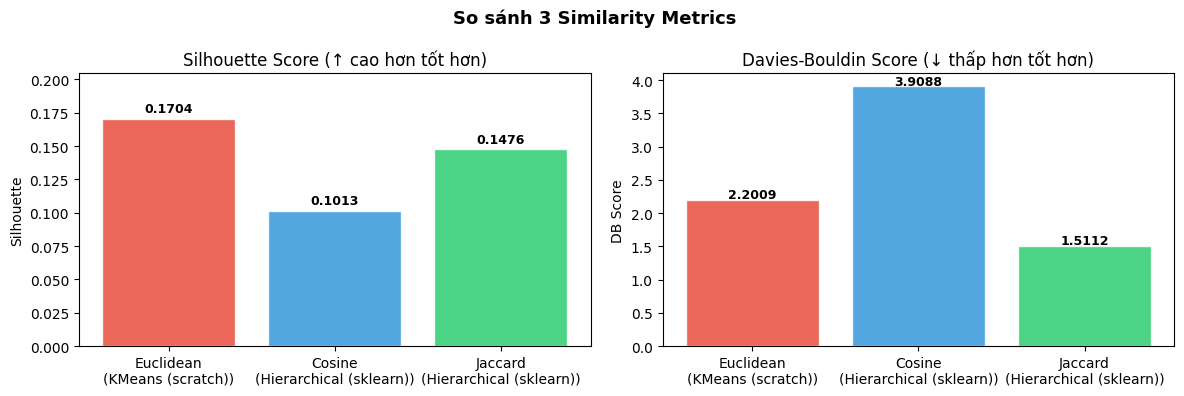

  Lưu: output_module2\04_metric_comparison.png


In [11]:
BEST_K = 4   # bo comment de ep cung K=4

model = PatientClustering(best_k=BEST_K, random_state=settings.random_state)
model.fit(
    X_pca          = vec.X_pca,
    X_scaled       = vec.X_scaled,
    X_binary       = vec.X_binary,
    patient_ids    = vec.patient_ids,
    cosine_sample  = settings.cosine_sample,
    jaccard_sample = settings.jaccard_sample,
)

comparison_df = model.get_comparison_df()
print("\n" + comparison_df.to_string(index=False))

plot_metric_comparison(comparison_df, settings.output_dir)

## Cell 11 — Đặt tên cluster
Xem output Cell 10 để đặt tên phù hợp

In [12]:
cluster_names = {
    0: "Cardiac / Heart Failure",
    1: "Sepsis / Infection",
    2: "Respiratory",
    3: "Renal / Metabolic",
    4: "Neurological",
    5: "Oncology",
    6: "General / Mixed",
    7: "Elderly / Comorbid",
}
cluster_names = {k: v for k, v in cluster_names.items() if k < BEST_K}

model.set_cluster_names(cluster_names)
vec.feature_df["cluster_kmeans"] = model.labels_kmeans
vec.feature_df["cluster_name"]   = vec.feature_df["cluster_kmeans"].map(cluster_names)

for k, name in cluster_names.items():
    cnt = (vec.feature_df["cluster_kmeans"] == k).sum()
    print(f"  C{k}: '{name}' — {cnt:,} benh nhan")

  C0: 'Cardiac / Heart Failure' — 32,667 benh nhan
  C1: 'Sepsis / Infection' — 49,355 benh nhan
  C2: 'Respiratory' — 105,939 benh nhan
  C3: 'Renal / Metabolic' — 23,524 benh nhan


## Cell 12 — Visualizations

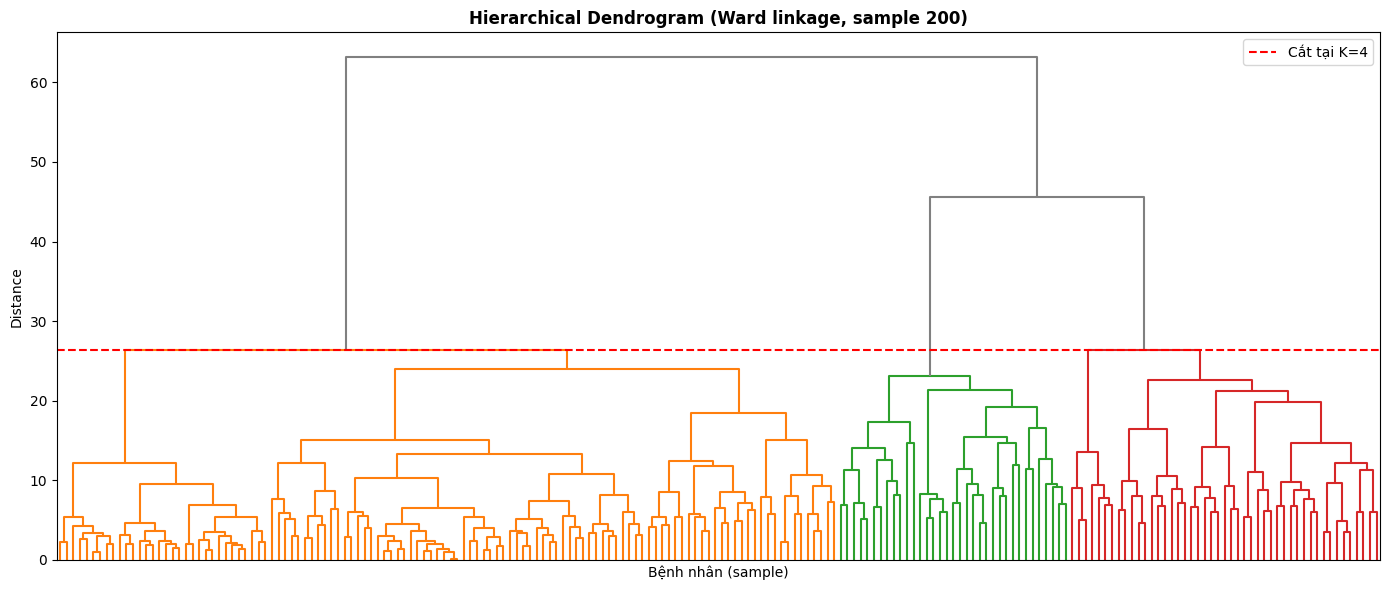

  Lưu: output_module2\05_dendrogram.png


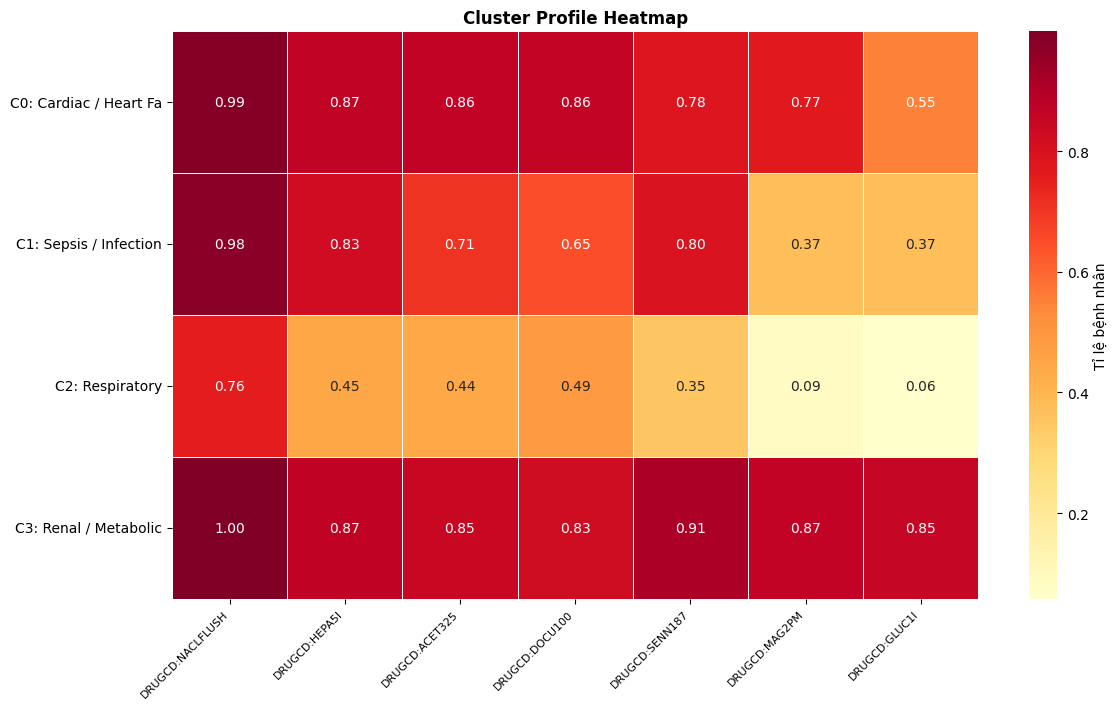

  Lưu: output_module2\06_cluster_heatmap.png
  t-SNE K-means (Euclidean) trên 5,000 bệnh nhân ...


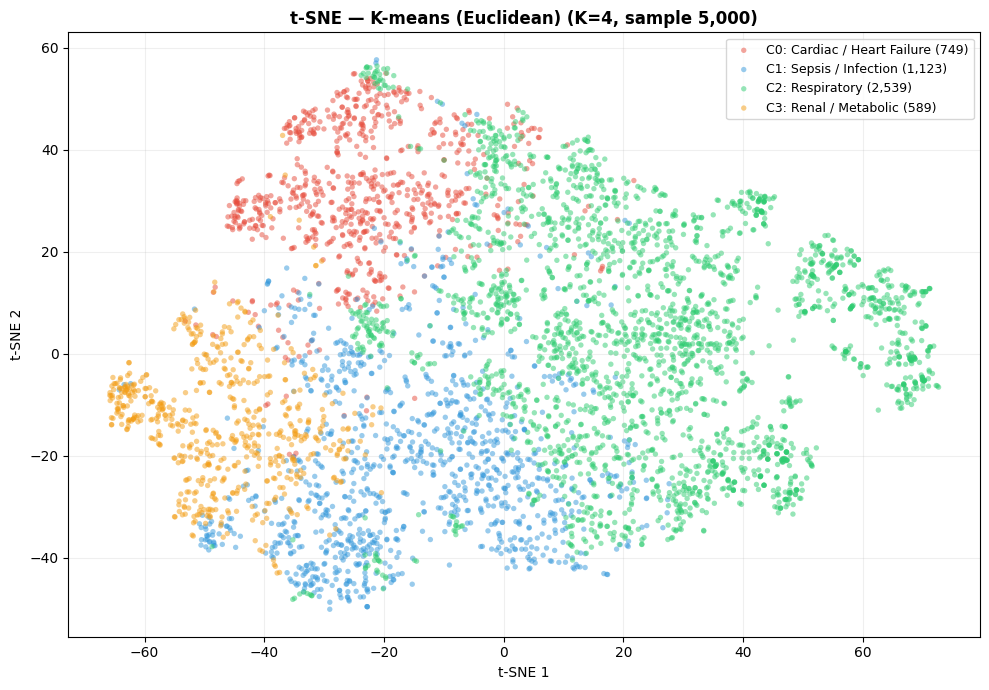

  Lưu: output_module2\07a_tsne_kmeans.png
  t-SNE Hierarchical (Cosine) trên 5,000 bệnh nhân ...


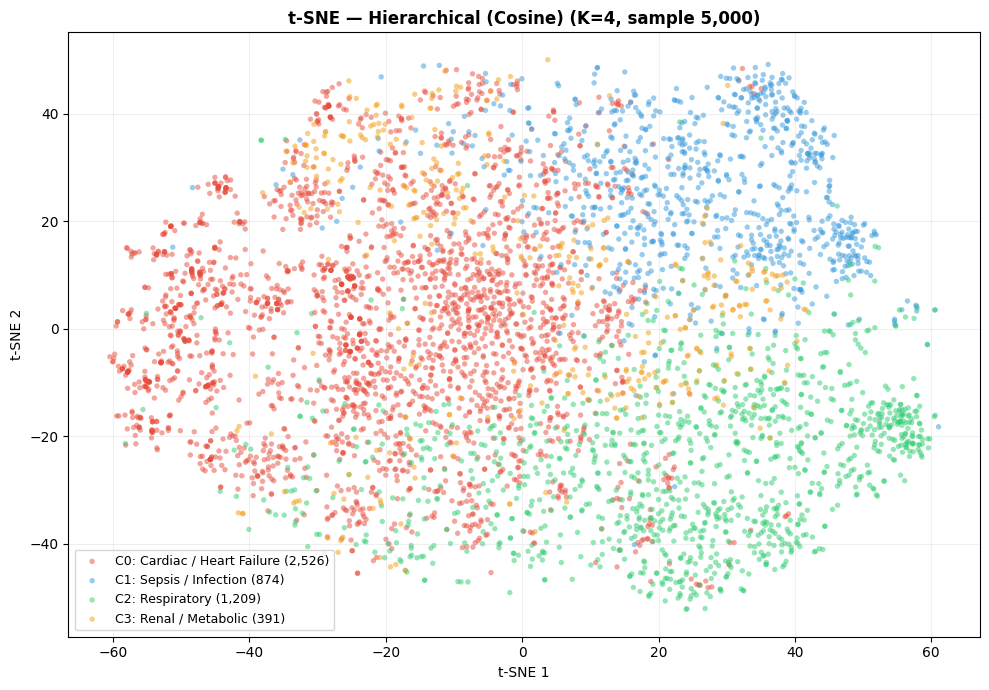

  Lưu: output_module2\07b_tsne_cosine.png


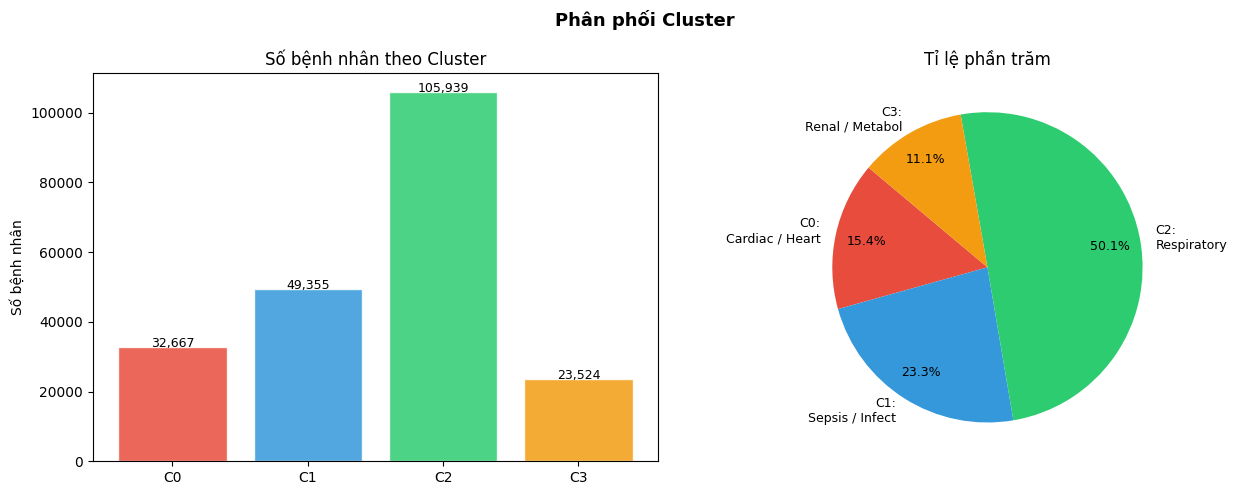

  Lưu: output_module2\08_cluster_distribution.png


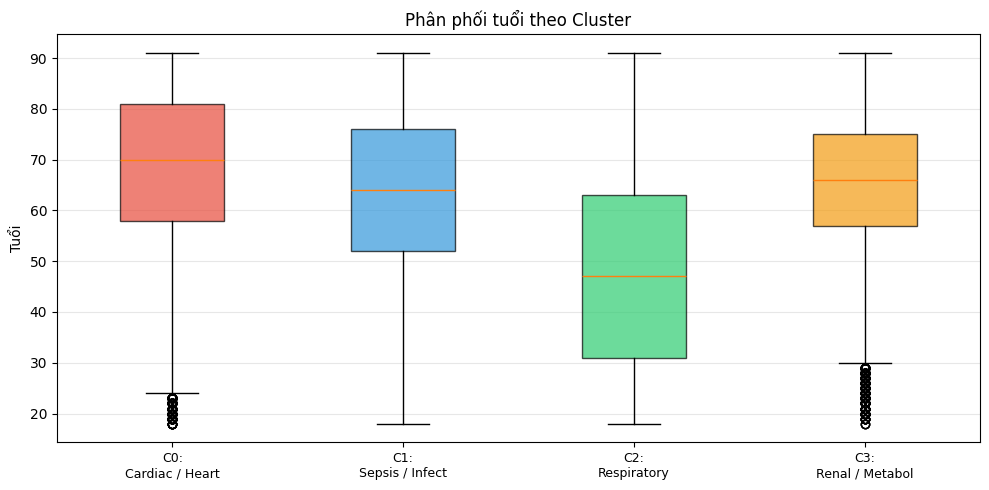

  Lưu: output_module2\09_age_by_cluster.png


In [13]:
plot_dendrogram(
    vec.X_pca, model.labels_kmeans,
    BEST_K, settings.dendro_sample, settings.random_state,
    settings.output_dir
)

plot_cluster_heatmap(
    vec.feature_df, vec.icd_cols, vec.drug_cols,
    cluster_names, BEST_K, settings.output_dir
)

# t-SNE K-means (Euclidean)
plot_tsne(
    vec.X_pca, model.labels_kmeans, cluster_names, BEST_K,
    settings.tsne_sample, settings.random_state,
    "K-means (Euclidean)", "07a_tsne_kmeans.png",
    settings.output_dir
)

# t-SNE Hierarchical Cosine
plot_tsne(
    vec.X_scaled, model.labels_cosine, cluster_names, BEST_K,
    settings.tsne_sample, settings.random_state,
    "Hierarchical (Cosine)", "07b_tsne_cosine.png",
    settings.output_dir
)

plot_distribution(
    vec.feature_df, cluster_names, BEST_K, settings.output_dir
)

## Cell 13 — Test assign bệnh nhân mới

In [14]:
# Bệnh nhân mới: 65 tuổi, Nam, suy tim + Furosemide
vec_scaled, vec_pca = vec.transform_new_patient(
    age         = 65,
    gender      = "M",
    icd_tokens  = ["ICD10:I50.9", "ICD10:J18.9"],
    drug_tokens = ["DRUGCD:FURO40", "DRUGCD:LISI10"],
)

result = model.assign_new_patient(vec_scaled, vec_pca)

print(f"Cluster ID   : {result.cluster_id}")
print(f"Cluster Name : {result.cluster_name}")
print(f"Confidence   : {result.confidence:.2%}")
print(f"\nEuclidean distances to centroids:")
for name, dist in result.distances_euclidean.items():
    print(f"  {name}: {dist:.4f}")
print(f"\nCosine similarity to centroids:")
for name, sim in result.cosine_sim_to_centroids.items():
    print(f"  {name}: {sim:.4f}")

Cluster ID   : 2
Cluster Name : Respiratory
Confidence   : 74.48%

Euclidean distances to centroids:
  C0:Cardiac / Heart Failure: 9.2744
  C1:Sepsis / Infection: 6.8091
  C2:Respiratory: 3.1970
  C3:Renal / Metabolic: 12.5295

Cosine similarity to centroids:
  C0:Cardiac / Heart Failure: -0.4908
  C1:Sepsis / Infection: -0.3921
  C2:Respiratory: 0.8200
  C3:Renal / Metabolic: -0.7050


## Cell 14 — Lưu output

In [15]:
out = settings.output_dir

# patient_clusters.csv  + Dashboard
clusters_df = pd.DataFrame({
    "subject_id"   : vec.patient_ids,
    "cluster_id"   : model.labels_kmeans,
    "cluster_name" : [cluster_names.get(k, f"C{k}") for k in model.labels_kmeans],
})
clusters_df.to_csv(out / "patient_clusters.csv", index=False)
print(f"Luu: patient_clusters.csv  ({len(clusters_df):,} rows)")

# metric_comparison.csv
comparison_df.to_csv(out / "metric_comparison.csv", index=False)
print(f"Luu: metric_comparison.csv")

# clustering_model.pkl
model.save(out / "clustering_model.pkl")
print(f"Luu: clustering_model.pkl")

# vectorizer.pkl
with open(out / "vectorizer.pkl", "wb") as f:
    pickle.dump(vec, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Luu: vectorizer.pkl")

print(f"\nTat ca output luu tai: {out}/")

# Dừng Spark
spark.stop()
print("Spark stopped.")

Luu: patient_clusters.csv  (211,485 rows)
Luu: metric_comparison.csv
Luu: clustering_model.pkl
Luu: vectorizer.pkl

Tat ca output luu tai: output_module2/
Spark stopped.
